In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import pickle
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import yaml

from neuralhydrology.modelzoo import get_model
from neuralhydrology.utils.config import Config
from neuralhydrology.modelzoo.cudalstm import CudaLSTM
from neuralhydrology.modelzoo.customlstm import CustomLSTM

In [2]:
# ------- Paths -------
model_dir=Path('../CHIRPS_2.0/runs/gauge_and_chirps_precip_seq_270_30_epochs_seq_270_hidden_256_dropout_04_fb_05_seed111_0402_180903')
pickle_file_dir = model_dir / 'validation' / 'model_epoch030' / 'validation_results.p'
pt_file_dir = model_dir / 'model_epoch030.pt'
optimizer_file_dir = model_dir / 'optimizer_state_epoch030.pt'
scaler_path = model_dir / "train_data" / "train_data_scaler.yml"

In [3]:
pt_data = torch.load(pt_file_dir,weights_only=True)
# pt_data

In [4]:
cfg = Config(model_dir / "config.yml")

In [5]:
optimized_model = CudaLSTM(cfg)
# print(optimized_model)

state_dict = torch.load(pt_file_dir)

optimized_model.load_state_dict(state_dict)
optimized_model.eval()

/tmp/ipykernel_10831/2693144925.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(pt_file_dir)


CudaLSTM(
  (embedding_net): InputLayer(
    (statics_embedding): Identity()
    (dynamics_embeddings): ModuleList(
      (0): Identity()
    )
  )
  (lstm): LSTM(16, 256)
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Regression(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=1, bias=True)
    )
  )
)

In [6]:
custom_lstm = CustomLSTM(cfg=cfg)

In [7]:
custom_lstm.copy_weights(optimized_model)

In [8]:
custom_lstm.eval()

CustomLSTM(
  (embedding_net): InputLayer(
    (statics_embedding): Identity()
    (dynamics_embeddings): ModuleList(
      (0): Identity()
    )
  )
  (cell): _LSTMCell()
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Regression(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=1, bias=True)
    )
  )
)

In [9]:
# SCALER

with open(scaler_path, "r") as f:
    scaler = yaml.safe_load(f)

In [10]:
# LOADING ATTRIBUTES
attributes_file = Path("../CHIRPS_2.0/filtered_data_gauge_and_CHIRPS/attributes/attributes.csv")

df_attr = pd.read_csv(attributes_file, index_col=0)
df_attr.head()

,slope_mean,p_mean,aridity,gauge_name,pet_mean,high_prec_dur,silt_frac,area_gages2,frac_snow,high_prec_freq,low_prec_dur,sand_frac,elev_mean,clay_frac,low_prec_freq
gauge_id,,,,,,,,,,,,,,,
CAMELS_UY_10,12.725907,3.915340,0.717773,Paso Mazangano,2.810326,1.203846,23.706791,6530.808541,0.0,0.064271,4.354260,46.015110,169.307582,30.243464,0.664613
CAMELS_UY_7,15.561201,3.970856,0.716361,Paso de Coelho,2.844567,1.221795,24.611382,2419.341041,0.0,0.065229,4.570572,46.167766,175.073007,29.245498,0.678234
CAMELS_UY_12,19.234042,3.411160,0.787933,Sarandi del Yi,2.687766,1.213033,22.247986,1381.247863,0.0,0.066256,4.813197,51.963862,198.932640,25.767853,0.708966
CAMELS_UY_8,14.357646,3.922811,0.712604,Paso de las Toscas,2.795410,1.232258,22.190911,970.932984,0.0,0.065366,4.561788,47.650490,151.682992,29.976673,0.684736
CAMELS_UY_15,12.119889,3.660062,0.817819,Paso de las Piedras (R3),2.993270,1.234536,25.837488,791.650467,0.0,0.065572,5.027247,43.814931,79.279041,30.758116,0.719849


In [11]:
# --- Define the features your model uses ---
static_features = [
    "elev_mean",
    "slope_mean",
    "area_gages2",
    "sand_frac",
    "silt_frac",
    "clay_frac",
    "p_mean",
    "pet_mean",
    "aridity",
    "high_prec_dur",
    "low_prec_dur"
]

In [12]:
# Ensure the index is a string
df_attr.index = df_attr.index.astype(str)

# Select your basin
basin = "CAMELS_UY_2"

# static_values
static_values = df_attr.loc[basin, static_features].to_numpy(dtype=np.float32)

attr_means = np.array([scaler["attribute_means"][k] for k in static_features], dtype=np.float32)
attr_stds  = np.array([scaler["attribute_stds"][k]  for k in static_features], dtype=np.float32)

static_norm = (static_values - attr_means) / attr_stds
static_tensor = torch.tensor(static_norm).unsqueeze(0)  # [1, n_static]

print(static_tensor.shape)
print(static_tensor)

torch.Size([1, 11])
tensor([[ 0.4445, -0.0506, -0.3513,  1.5605, -1.0947, -1.3870,  0.6382,  0.8166,
         -0.1449,  0.5908, -0.1740]])


In [13]:
# DYNAMIC INPUTS

def norm_dyn(tensor, varname):
    center = scaler["xarray_feature_center"]["data_vars"][varname]["data"]
    scale  = scaler["xarray_feature_scale"]["data_vars"][varname]["data"]
    center = torch.tensor(center, dtype=tensor.dtype, device=tensor.device)
    scale  = torch.tensor(scale,  dtype=tensor.dtype, device=tensor.device)
    return (tensor - center) / scale

In [14]:
ts_file = Path("../CHIRPS_2.0/filtered_data_gauge_and_CHIRPS/time_series") / f"{basin}.nc"

ds = xr.open_dataset(ts_file)
print(ds)

<xarray.Dataset> Size: 408kB
Dimensions:             (date: 11322)
Coordinates:
  * date                (date) datetime64[ns] 91kB 1989-01-01 ... 2019-12-31
Data variables:
    tmin_C              (date) float32 45kB ...
    tmax_C              (date) float32 45kB ...
    srad_W_m2           (date) float32 45kB ...
    prcp_mm_day         (date) float32 45kB ...
    QObs_mm_d           (date) float64 91kB ...
    prcp_chirps_mm_day  (date) float32 45kB ...
Attributes:
    precip_update:  Gauge data used where available


In [15]:
dynamic_vars = ["QObs_mm_d","prcp_mm_day","srad_W_m2","tmax_C","tmin_C","prcp_chirps_mm_day"]

In [16]:
# --- Convert xarray to DataFrame and sort by date ---
df_dyn = ds[dynamic_vars].to_dataframe().sort_index()
df_dyn

,QObs_mm_d,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,prcp_chirps_mm_day
date,,,,,,
1989-01-01,NaN,0.000000,259.260010,33.619999,20.469999,0.000000
1989-01-02,NaN,0.000000,285.109985,35.619999,22.809999,0.000000
1989-01-03,NaN,0.000000,304.019989,34.849998,20.690001,0.000000
1989-01-04,NaN,0.000000,304.600006,36.279999,22.320000,0.000000
1989-01-05,NaN,0.000000,299.529999,35.849998,22.820000,0.000000
...,...,...,...,...,...,...
2019-12-27,0.215204,0.000000,267.989990,35.700001,22.120001,0.000000
2019-12-28,0.173601,31.700001,238.220001,35.830002,23.480000,7.540442
2019-12-29,0.152305,0.000000,287.420013,34.660000,23.080000,0.134660


In [17]:
spinup_start = pd.to_datetime("1989-10-01")
spinup_end   = pd.to_datetime("2008-09-30")

spinup_df = df_dyn.loc[spinup_start:spinup_end][dynamic_vars]
spinup_df

,QObs_mm_d,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,prcp_chirps_mm_day
date,,,,,,
1989-10-01,0.169558,0.0,236.259995,23.719999,8.09,0.000000
1989-10-02,0.146150,0.3,174.929993,25.180000,12.27,1.540213
1989-10-03,0.131639,0.0,242.419998,21.809999,12.12,5.144664
1989-10-04,0.118475,0.0,251.619995,21.309999,7.79,0.000000
1989-10-05,0.111960,0.0,233.619995,24.090000,8.41,0.000000
...,...,...,...,...,...,...
2008-09-26,0.379056,0.0,198.970001,22.180000,11.51,0.000000
2008-09-27,0.312293,0.0,198.860001,22.900000,12.40,0.000000
2008-09-28,0.305509,0.3,216.389999,24.570000,12.49,0.000000


In [18]:
# --- Convert to tensor ---
spinup_tensor = torch.tensor(spinup_df.values.astype(np.float32)).unsqueeze(0)
print(spinup_tensor.shape)  # should be [1, 270, 4]

torch.Size([1, 6940, 6])


In [19]:
# historical_dynamic_tensor: [1, 270, 6] as you already computed
x_prcp      = spinup_tensor[..., 1:2]
x_srad      = spinup_tensor[..., 2:3]
x_tmax      = spinup_tensor[..., 3:4]
x_tmin      = spinup_tensor[..., 4:5]
x_prcp_ch   = spinup_tensor[..., 5:6]

x_prcp_norm    = norm_dyn(x_prcp,    "prcp_mm_day")
x_srad_norm    = norm_dyn(x_srad,    "srad_W_m2")
x_tmax_norm    = norm_dyn(x_tmax,    "tmax_C")
x_tmin_norm    = norm_dyn(x_tmin,    "tmin_C")
x_prcp_ch_norm = norm_dyn(x_prcp_ch, "prcp_chirps_mm_day")

spinup_inputs = {
    "x_d": {
        "prcp_mm_day":        x_prcp_norm,
        "srad_W_m2":          x_srad_norm,
        "tmax_C":             x_tmax_norm,
        "tmin_C":             x_tmin_norm,
        "prcp_chirps_mm_day": x_prcp_ch_norm,
    },
    "x_s": static_tensor
}

In [20]:
spinup_inputs = {
    "x_d": {k: v for k, v in spinup_inputs["x_d"].items()},
    "x_s": spinup_inputs["x_s"]
}

with torch.no_grad():
    out = custom_lstm(spinup_inputs)

# h0 = out["h_n"]
# c0 = out["c_n"]
h_val = out["h_n"][:, -1, :]
c_val = out["c_n"][:, -1, :]
y_hat = out["y_hat"]

# print("h0 shape:", h0.shape)
# print("c0 shape:", c0.shape)
print("Predictions shape:", y_hat.shape)
print("First 10 predictions (normalized):", y_hat[0, :10, 0])

Predictions shape: torch.Size([1, 6940, 1])
First 10 predictions (normalized): tensor([-0.0589,  0.0062,  0.0762,  0.0602,  0.0085, -0.0706, -0.1056, -0.1693,
        -0.2195, -0.2687])


In [21]:
q_center = scaler["xarray_feature_center"]["data_vars"]["QObs_mm_d"]["data"]
q_scale  = scaler["xarray_feature_scale"]["data_vars"]["QObs_mm_d"]["data"]

q_center = torch.tensor(q_center, dtype=y_hat.dtype, device=y_hat.device)
q_scale  = torch.tensor(q_scale,  dtype=y_hat.dtype, device=y_hat.device)

y_hat_denorm = y_hat * q_scale + q_center
print("First 10 predictions (mm/d):", y_hat_denorm[0, :10, 0].cpu().numpy())

First 10 predictions (mm/d): [1.3776143  1.6268213  1.8942904  1.8330536  1.635638   1.3330435
 1.1990958  0.95571584 0.76355594 0.5753163 ]


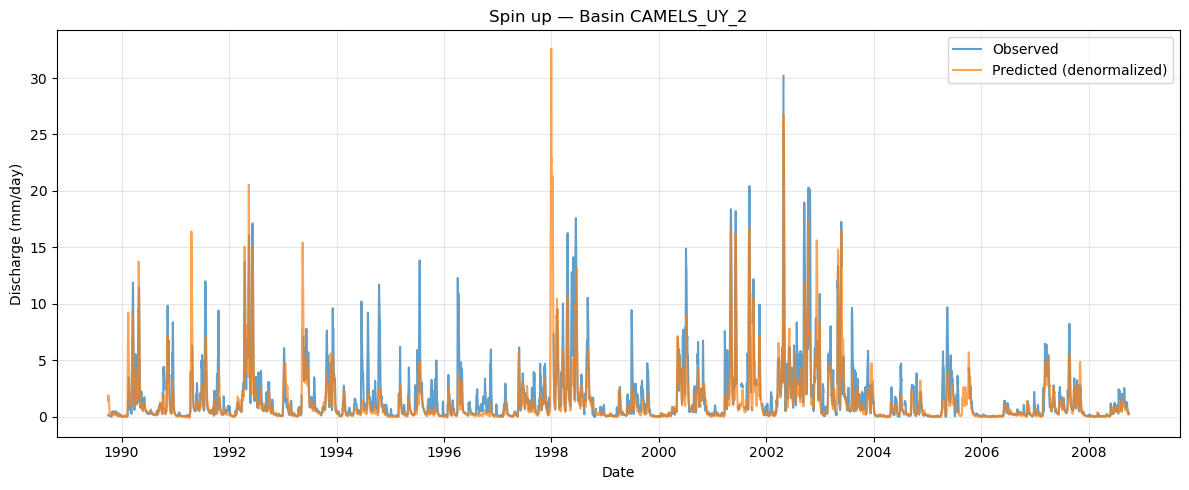

In [22]:
# --- Extract numpy arrays ---
pred = y_hat_denorm[0, :, 0].cpu().numpy()     # [270]
obs  = spinup_df["QObs_mm_d"].values          # [270]
dates = spinup_df.index                       # DatetimeIndex

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(dates, obs, label="Observed", alpha=0.7)
plt.plot(dates, pred, label="Predicted (denormalized)", alpha=0.7)

plt.title(f"Spin up — Basin {basin}")
plt.xlabel("Date")
plt.ylabel("Discharge (mm/day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Now its turn for the ensemble streamflow prediction

In [23]:
prediction_start = pd.to_datetime("2008-10-01")
prediction_end   = pd.to_datetime("2008-12-31")

In [24]:
predictions_dict = {
    "year": [],
    "prediction": []
}  

for year in range(1989, 2009):
    start = pd.to_datetime(f"{year}-10-01")
    end   = pd.to_datetime(f"{year}-12-31")

    historical_df = df_dyn.loc[start:end][dynamic_vars]

    historical_df.index = historical_df.index.map(lambda d: d.replace(year=2008))

    historical_tensor = torch.tensor(historical_df.values.astype(np.float32)).unsqueeze(0)

    # historical_dynamic_tensor: [1, 270, 6] as you already computed
    x_prcp_h      = historical_tensor[..., 1:2]
    x_srad_h      = historical_tensor[..., 2:3]
    x_tmax_h      = historical_tensor[..., 3:4]
    x_tmin_h      = historical_tensor[..., 4:5]
    x_prcp_ch_h   = historical_tensor[..., 5:6]

    x_prcp_norm_h    = norm_dyn(x_prcp_h,    "prcp_mm_day")
    x_srad_norm_h    = norm_dyn(x_srad_h,    "srad_W_m2")
    x_tmax_norm_h    = norm_dyn(x_tmax_h,    "tmax_C")
    x_tmin_norm_h    = norm_dyn(x_tmin_h,    "tmin_C")
    x_prcp_ch_norm_h = norm_dyn(x_prcp_ch_h, "prcp_chirps_mm_day")

    historical_inputs = {
        "x_d": {
            "prcp_mm_day":        x_prcp_norm_h,
            "srad_W_m2":          x_srad_norm_h,
            "tmax_C":             x_tmax_norm_h,
            "tmin_C":             x_tmin_norm_h,
            "prcp_chirps_mm_day": x_prcp_ch_norm_h,
        },
        "x_s": static_tensor
    }

    historical_inputs = {
        "x_d": {k: v for k, v in historical_inputs["x_d"].items()},
        "x_s": historical_inputs["x_s"]
    }

    with torch.no_grad():
        out = custom_lstm(historical_inputs, h_0=h_val, c_0=c_val) #h_val and c_val come from the spin up phase

    #predictions
    y_hat = out["y_hat"]

    # Denormalize predictions
    q_center = scaler["xarray_feature_center"]["data_vars"]["QObs_mm_d"]["data"]
    q_scale  = scaler["xarray_feature_scale"]["data_vars"]["QObs_mm_d"]["data"]

    q_center = torch.tensor(q_center, dtype=y_hat.dtype, device=y_hat.device)
    q_scale  = torch.tensor(q_scale,  dtype=y_hat.dtype, device=y_hat.device)

    y_hat_denorm = y_hat * q_scale + q_center

    # Store predictions in the dictionary
    predictions_dict["year"].append(year)         
    predictions_dict["prediction"].append(y_hat_denorm[0, :, 0].cpu().numpy())

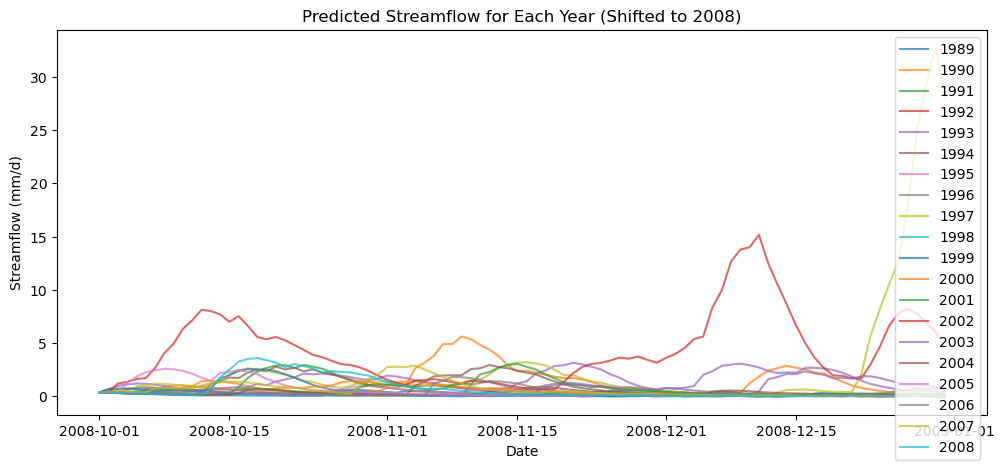

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

# Fixed date range for x-axis
dates = pd.date_range(start="2008-10-01", end="2008-12-31")

for i, year in enumerate(range(1989, 2009)):
    pred = predictions_dict["prediction"][i]  # numpy array of predictions
    ax.plot(dates, pred, label=f"{year}", alpha=0.7)

ax.set_xlabel("Date")
ax.set_ylabel("Streamflow (mm/d)")
ax.set_title("Predicted Streamflow for Each Year (Shifted to 2008)")
ax.legend()
plt.show()


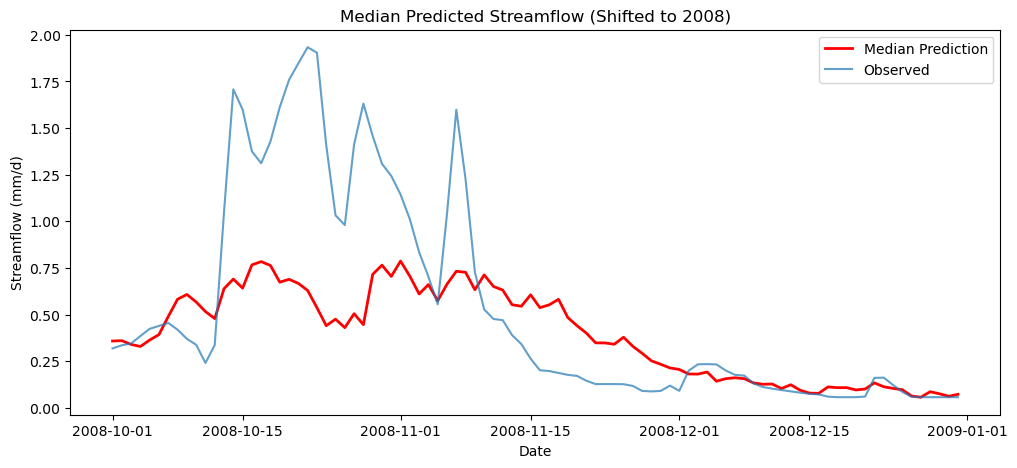

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

# Fixed date range for x-axis
dates = pd.date_range(start="2008-10-01", end="2008-12-31")

# Stack all predictions into a 2D array: [n_years, n_days]
all_preds = np.array(predictions_dict["prediction"])  # shape: (20, n_days)

# Compute median across years (axis=0)
median_pred = np.median(all_preds, axis=0)

# Extrac observed values for the same date range
obs_df = df_dyn.loc["2008-10-01":"2008-12-31"]
obs = obs_df["QObs_mm_d"].values

# Plot median
ax.plot(dates, median_pred, color="red", label="Median Prediction", linewidth=2)
ax.plot(dates, obs, label="Observed", alpha=0.7)

ax.set_xlabel("Date")
ax.set_ylabel("Streamflow (mm/d)")
ax.set_title("Median Predicted Streamflow (Shifted to 2008)")
ax.legend()
plt.show()